
# 回帰モデルのscaling即

## 導入

- $N$: number of data instances
- $p$: モデルの自由度
- $L$: loss function, or 評価指標

RMSEに対して、テストデータに対して理想的な統計的RMSEは

$$ RMSE(N) \sim \sigma \sqrt{1 + p/N} $$

であることが知られている。
ここで、理想的とは、データが完全に線形で独立で多重共線性がなく、データ生成時のノイズが正規分布ということ。

$\sigma$は観測ノイズの標準偏差。もしくは、単にデータが無限大の時のRMSEの漸近値である。

大規模言語モデルなどの
大規模ニューラルネットワークモデル（パラメタ数p)に対して、
N<<pの場合は、テストデータに対して妥当なモデルが作れる場合、以下の
$L$と$N$の関係が成り立つ場合がある。

$$ L(N) = L_0 + a N^{-b} $$

つまり、損失関数や関連した予測性能評価指標がNのべきで減少し、定数漸近する。


これにより

1. データを追加取得すると回帰性能がどの程度改善するはずなのか。
2. また、使用しているモデルや記述子でデータが無限にあった場合の回帰性能が分かる。（外挿領域を除く。）

### 参考文献

１と２．大規模言語モデルの例がよく知られている。TOKENがデータインスタンス数に対応する。
３．人工合成した画像データ（化学合成データではない）の例。
４．転移学習の例

1. Scaling Laws for Neural Language Models,
Jared Kaplan, Sam McCandlish, Tom Henighan, Tom B. Brown, Benjamin Chess, Rewon Child, Scott Gray, Alec Radford, Jeffrey Wu, Dario Amodei, https://arxiv.org/abs/2001.08361

1. Training Compute-Optimal Large Language Model,
Hoffmann, J., Borgeaud, S., Mensch, A., Buchatskaya, E., Cai, T., Rutherford, E., … Sifre, L. (2022). arXiv preprint arXiv:2203.15556.

1. Mikami, H. et al. (2023). A Scaling Law for Syn2real Transfer: How Much Is Your Pre-training Effective?. In: Amini, MR., Canu, S., Fischer, A., Guns, T., Kralj Novak, P., Tsoumakas, G. (eds) Machine Learning and Knowledge Discovery in Databases. ECML PKDD 2022. Lecture Notes in Computer Science(), vol 13715. Springer, Cham. https://doi.org/10.1007/978-3-031-26409-2_29, 
also https://arxiv.org/abs/2108.11018

1. Scaling law of Sim2Real transfer learning in expanding computational materials databases for real-world predictions, Mikami et al., https://www.nature.com/articles/s41524-025-01606-5

## 本スクリプトの目的

分子第一原理計算大規模データセットを用いて回帰モデルのscaling即が成り立つかを検証する。
ただし、ニューラルネットワークモデルでなく、ランダムフォレスト回帰モデルと線型回帰モデル、またN>>pの場合を行なう。


## データセット

- QM9 dataset 
量子力学計算データセット

130,000 molecules with 19 regression targets.

目的変数
- HOMO level
- LUMO level
- band gap
- ...
- Heat capavity at 298.15K

band gap (GAP)を目的変数に用いる。

文献：

1. MoleculeNet: A Benchmark for Molecular Machine Learning
Zhenqin Wu, Bharath Ramsundar, Evan N. Feinberg, Joseph Gomes, Caleb Geniesse, Aneesh S. Pappu, Karl Leswing, Vijay Pande,  https://arxiv.org/abs/1703.00564

### QM9 datasetの特徴量についてはこちらを参照

https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html

## 説明変数

Morgan fingerprint

## install

torch_geometric, rdkit, arviz
のインストールが必要です。


## 
分子の固定長説明変数

分子例）エタノール CH3-CH2-OH, 
に対して説明

![](image_keep/CH3CH2OH.png)
![](image_keep/CH3CH2OH_3D.png)

図はhttps://ja.wikipedia.org/wiki/%E3%82%A8%E3%82%BF%E3%83%8E%E3%83%BC%E3%83%AB
から取得 Nov. 26, 2025

SMILESではエタノールをCCOと書く。

SMILESを用いて、
分子の固定長説明変数に
Morgan Fingerprintが有名である。


これは分子をその結合を用いて、

- 半径０：中心原子の特徴
- 半径１：隣との原子の関係
- 半径２：２つ隣との原子の関係

を表す手法である。

以下、
半径０，半径１，半径２を用いて
簡単なFingerprint作成例を考える。 
（Morgan Fingerprintではない）

### fingerprint toy model例

### 半径０（中心原子の特徴）

半径０（中心原子の特徴）
として、その原子の元素、形式電荷、芳香族フラグ、付加水素数１，付加水素数２，付加水素数３を考える。


| 特徴 / 原子         | C (1番目) | C (2番目) | O |
|---------------------|-----------|-----------|---|
| C                   | 1         | 1         | 0 |
| N                   | 0         | 0         | 0 |
| O                   | 0         | 0         | 1 |
| 形式電荷 0          | 1         | 1         | 1 |
| 芳香性フラグ        | 0         | 0         | 0 |
| 付加水素数 1        | 0         | 0         | 1 |
| 付加水素数 2        | 0         | 1         | 0 |
| 付加水素数 3        | 1         | 0         | 0 |

この特徴量は
8 bitsで表すことが可能。つまり
1. C (1番目) = 10010001 
2. C (2番目) = 10010010
3. O = 00110100

と書ける。

#### 半径1（隣との原子の関係）

ある原子からみて、隣の原子種類を記述する。

| 特徴 / 原子                   | C (1番目) | C (2番目) |  |
|------------------------------|-----------|-----------|----|
| 隣が CH3                     | 0         | 1         | 0  |
| 隣が CH2                     | 1         | 0         | 1  |
| 隣が CH                      | 0         | 0         | 0  |
| 隣が OH                      | 0         | 1         | 0  |
| 隣が 芳香環の側鎖            | 0         | 0         | 0  |


この特徴量は
5 bitsで表すことが可能。つまり

1. C (1番目)  = 01000 
2. C (2番目) = 10010
3. O = 01000


### 半径2　（ ２つ隣との原子の関係）

| 特徴 / 原子     | C (1番目) | C (2番目) | O  |
|------------------|-----------|-----------|----|
| 2 step 先が C    | 0         | 0         | 1  |
| 2 step 先が O    | 1         | 0         | 0  |
| 2 step 先が N    | 0         | 0         | 0  |

この特徴量は
3 bitsで表すことが可能。
つまり、

1. C (1番目)  = 010 
2. C (2番目) = 000
3. O = 100

### 原子のfingerprint

半径0, 1,2のbitsを右からつなげて書くと全部書くと、

|原子ID| 分子内原子表現 | 対応する文字表現 |
|---|---|---|
| C (1番目) | 010 01000 10010001 |CH3、隣がCH2、２つ隣がO|
|C (2番目)|  000 10010 10010010 | CH2、隣がCH3とOH |
| O | 100 01000 00110100 | OH、隣がCH2、２つ隣がC |


### 分子fingerprint
bitのORを取る。

|分子|
|---|
|110 10110 11111010| 


細かい特徴を入れればいくらでもbits数は増える。
しかし、分子により長さが異なると使いにくいので、固定長にする。

### 固定長への変換

固定長のbitsにすることをハッシュ化するという。ハッシュ化された値はハッシュ値と呼ぶ。

今の例の場合に、ハッシュ化すると…

- 11bitsの場合：
隣がCH,CH2,CH3かの区別がなくなり、２つ隣の区別がなくなる。（それらが同じ表現になる。）
- 14bitsの場合：
２つ隣の区別がなくなる。

| 使用bit数 |ハッシュ値|
|---|---|
|右側の11bits使う | 10 11111010 |
|右側の14bits使う | 10110 11111010 |

一つのfingerprintで複数の構造を表すことになる。
このため、
（予測値に大きな影響を及ぼさないように）右側のbitほど重要な特徴量を入れるように特徴量を配置する。

RDkitで、
分子のSMILESから作ることができるfingerprintは多種ある。

例）
Morgan fingerprint（FP): Functional Class FP, Extended Connectivity FP, Topological FP, Atom Pair FP, Topological Torsion FP, MACCS Keys, Avalon FP, …

#### bits数
Morgan fingerprintでは1024 bits, 2048 bitsなど多くの特徴を用いる。つまり、0または1を取る説明変数の数が1024もしくは2048ある。


### モデルの変数の数とデータの数

- 変数の数P : 1024
- データの数N

通常はN>>Pに対してモデルをつくる。

（線型回帰モデルで安定させるために、penalty項を入れた。）


In [1]:
# rdkitのversionを確認
# 最近APIが変更されました。
# このためLLMに尋ねる場合はversionも指示してください。

import rdkit
print(rdkit.__version__)


2025.09.1


## torch-geometricのinstall
1. QM9データベースを使うにはtorch-geometricのインストールが必要。

```
pip install torch-geometric
```

2. インターネットでデータ本体のダウンロードを行なう必要がある。

In [2]:
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import ConvertToNumpyArray

from torch_geometric.datasets import QM9
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [3]:
# QM9 データセットをdata/qm9ディレクトリにダウンロードする。

import pandas as pd

def load_qm9_dataframe(root="data/qm9"):

    # -----------------------------
    # 1. Load QM9 dataset (PyG)
    # -----------------------------
    dataset = QM9(root=root)
    print("Total molecules:", len(dataset))

    IDX_HOMO = 2
    IDX_LUMO = 3
    IDX_GAP = 4
    
    # PyG の dataset をそのまま pandas Series にする
    s = pd.Series(dataset)
    
    # HOMO/LUMO/GAP を 1 サンプルずつ抽出する関数
    def extract_y(data):
        y = data.y[0]  # shape [19]
        return pd.Series({
            "SMILES": data.smiles,
            "HOMO":   y[IDX_HOMO].item(),
            "LUMO":   y[IDX_LUMO].item(),
            "GAP":    y[IDX_GAP].item(),
        })
    
    # apply で一気に DataFrame に展開
    df = s.apply(extract_y)
    return df    

df = load_qm9_dataframe()

print(df.head())


Total molecules: 130831
              SMILES       HOMO      LUMO        GAP
0  [H]C([H])([H])[H] -10.549854  3.186453  13.736308
1       [H]N([H])[H]  -6.993326  2.255824   9.249149
2            [H]O[H]  -7.967494  1.869422   9.836916
3          [H]C#C[H]  -7.741639  1.376896   9.118535
4             [H]C#N  -9.806983  0.519737  10.329442


In [4]:
df.to_csv("data_calculated/qm9.csv", index=False)

In [5]:
df

,SMILES,HOMO,LUMO,GAP
0,[H]C([H])([H])[H],-10.549854,3.186453,13.736308
1,[H]N([H])[H],-6.993326,2.255824,9.249149
2,[H]O[H],-7.967494,1.869422,9.836916
3,[H]C#C[H],-7.741639,1.376896,9.118535
4,[H]C#N,-9.806983,0.519737,10.329442
...,...,...,...,...
130826,[H]C1([H])[C@@]2([H])[N@@H+]3[C@@]2([H])[C@@]2...,-6.133446,1.600029,7.733476
130827,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,-6.511684,1.654452,8.168858
130828,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,-6.076303,1.959220,8.035522
130829,[H]C1([H])[N@H+]2[C@@]3([H])[C@@]14C([H])([H])...,-5.774256,2.397323,8.171579


In [6]:
# define target variable
target = "GAP" # HOMO-LUMO gap
# target = "HOMO" # HOMO level
# target = "LUMO" # LUMO level


In [7]:
# SMILES表記からMorgan fingerprintの作成を行なう。
# 半径２
# 1024bits用いる。
def add_fingerprint(df):

    # -----------------------------
    # Morgan Fingerprint generator
    # -----------------------------
    RADIUS = 2
    N_BITS = 1024
    
    mfgen = rdFingerprintGenerator.GetMorganGenerator(
        radius=RADIUS,
        fpSize=N_BITS
    )
    
    # -----------------------------
    # 3. Convert molecules → FP
    # -----------------------------
    from rdkit import Chem
    
    def smiles_to_morgan(smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return mfgen.GetFingerprintAsNumPy(mol)  # (1024,) np.ndarray

    df["FP"] = df["SMILES"].apply(smiles_to_morgan)
    return df

df = add_fingerprint(df)

# Errorが出るが後で削除する。

[15:57:10] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[15:57:10] Explicit valence for atom # 3 C, 5, is g

In [8]:
# エラーが出た一部の分子のSMILESはrdkitライブラリに対応していないので削除する。

def clean_fingerprint_in_dataframe(df):

    bad = []
    
    for i, fp in enumerate(df["FP"]):
        if not isinstance(fp, np.ndarray):
            bad.append(i)
        elif fp.shape != (1024,):
            bad.append(i)
    
    print("Bad FP rows:", bad[:20])
    print("Total bad:", len(bad))
    
    df_clean = df[df["FP"].apply(lambda x: isinstance(x, np.ndarray) and x.shape == (1024,))].copy()
    df_clean = df_clean.reset_index(drop=True)

    return df_clean

df_clean = clean_fingerprint_in_dataframe(df)


Bad FP rows: [102, 307, 642, 644, 687, 689, 1118, 1845, 1949, 1953, 1956, 1959, 1964, 1990, 1992, 2354, 2355, 2362, 2365, 2366]
Total bad: 1819


In [9]:
# 確認のため表示
# Hがあっても変換できている。
print(target)
df_clean

GAP


,SMILES,HOMO,LUMO,GAP,FP
0,[H]C([H])([H])[H],-10.549854,3.186453,13.736308,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,[H]N([H])[H],-6.993326,2.255824,9.249149,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,[H]O[H],-7.967494,1.869422,9.836916,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,[H]C#C[H],-7.741639,1.376896,9.118535,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,[H]C#N,-9.806983,0.519737,10.329442,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
129007,[H]C1([H])[C@@]23[N@H+]4[C@@]5([H])[C@]1([H])[...,-6.065418,2.658552,8.723970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
129008,[H]C1([H])[C@@]2([H])[C@@]3([H])[C@@]14O[C@]1(...,-6.604203,2.459909,9.064113,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
129009,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,-6.076303,1.959220,8.035522,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
129010,[H]C1([H])[N@H+]2[C@@]3([H])[C@@]14C([H])([H])...,-5.774256,2.397323,8.171579,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [10]:
# 解析結果の保存用関数
import os
def save_model(df_scaling_data, target,  filename="scaling.csv", overwrite=False):

    if overwrite:
        df_scaling_data.to_csv(filename,index=False)
        print(f"data saved to {filename}")
    elif not os.path.isfile(filename):
        df_scaling_data.to_csv(filename,index=False)
        print(f"data saved to {filename}")
        
    else:
        print("Warning: file exists. not saved.")

In [29]:
# scaling lawを検証するためのデータを作成する関数
# scaling lawを計算するには
# 1. 様々なNに対して、L(D)か性能評価指標を計算して（データを作る）
# 2. L(N) = L0 + a N^{-b}でfitする。

# データを作るための関数

from sklearn.linear_model import RidgeCV

model_name = "ridge"
# model_name = "rf"


def make_scaling_law_data(df_clean,*, n_try=10, n_samples_list=None, model_name="rf"):
    if n_samples_list is None:
        n_samples_list = [100,200,500,1000,2000,5000, 10_000, 20_000, 50_000]
        #n_samples_list = np.logspace(2,5, 10)
        #n_samples_list = np.round(n_samples_list).astype(int).tolist()
    print(f"train the model {n_try} times")
    print(f"n_samples_list={n_samples_list}")
    scaling_law = []
    random_state = 0
    for n_samples in n_samples_list:
        print(f"n_samples={n_samples}")
        for _ in range(n_try):
            random_state += 1
            df_sample = df_clean.sample(n=n_samples, random_state=random_state)
            
            X = np.vstack(df_sample["FP"].values)
            y = df_sample[target].values
            
            # -----------------------------
            # 4. Train/Test split
            # -----------------------------
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.1, shuffle=False # shuffle is already done in df_clean.sample
            )
            
            # -----------------------------
            # 5. Train a model
            # -----------------------------
            if model_name == "rf":
                model = RandomForestRegressor(
                    n_estimators=100,
                    max_depth=None,
                    random_state = random_state, 
                    n_jobs=-1 # max. parallel 
                )
                model.fit(X_train, y_train)

            elif model_name == "ridge":
                model = RidgeCV(
                    alphas = np.logspace(-3, 2, 6),
                    scoring="neg_mean_squared_error",  # MSE 最小化
                    cv=5                               # 5-fold CV
                )
                model.fit(X_train, y_train)            
                print({"alpha_best": model.alpha_})          # 最適なα
            else:
                print(f"unknown model_name={model_name}")
                raise ValueError(f"unknown model_name={model_name}")
                
            pred_h = model.predict(X_test)
            
            r2 = r2_score(y_test, pred_h)
            mae = mean_absolute_error(y_test, pred_h)
            mse = mean_squared_error(y_test, pred_h)
            
            scaling_law.append({"n_samples": n_samples, "R2": r2, "MAE": mae,"MSE": mse})
    return pd.DataFrame(scaling_law), {"X":X_test, "y": y_test, "y_pred": pred_h}



In [30]:
# filename_readがあればそれから読み込む
# filename_writeがあればそれから読み込む
# ファイルがなければ、計算する。filename_writeへ書き込む。
def save_read_scaling_data(df_clean,target, *, model_name="rf", n_try=10):
    filename_read = f"data_keep/scaling_{target}_{model_name}.csv"
    filename_write = f"data_calculated/scaling_{target}_{model_name}.csv"
    if os.path.isfile(filename_read):
        print(f"load calculated data from {filename_read}")
        df_scaling_data = pd.read_csv(filename_read,index_col=None)
    elif os.path.isfile(filename_write):
        print(f"load calculated data from {filename_write}")
        df_scaling_data = pd.read_csv(filename_write,index_col=None)    
    else:
        # n_samples_list = [100,200,500,1000, 2000] # これは動作チェック用のsmall test
        n_samples_list = None
        df_scaling_data, test_prediction = make_scaling_law_data(df_clean, n_try=n_try, 
                                                                 n_samples_list=n_samples_list,model_name=model_name)
        
        save_model(df_scaling_data, target, filename_write)
    return df_scaling_data

df_scaling_data_all = save_read_scaling_data(df_clean,target, model_name=model_name)
df_scaling_data = df_scaling_data_all.copy()

load calculated data from data_keep/scaling_GAP_ridge.csv


In [31]:
df_scaling_data

,n_samples,R2,MAE,MSE
0,2154,0.690997,0.533888,0.457476
1,2154,0.661774,0.572966,0.560919
2,2154,0.727319,0.524352,0.426599
3,2154,0.746593,0.477968,0.389814
4,2154,0.676132,0.566956,0.524233
5,2154,0.658769,0.586447,0.568578
6,2154,0.579121,0.616774,0.697566
7,2154,0.676909,0.538001,0.483121
8,2154,0.711361,0.514637,0.448283
9,2154,0.640116,0.575540,0.580067


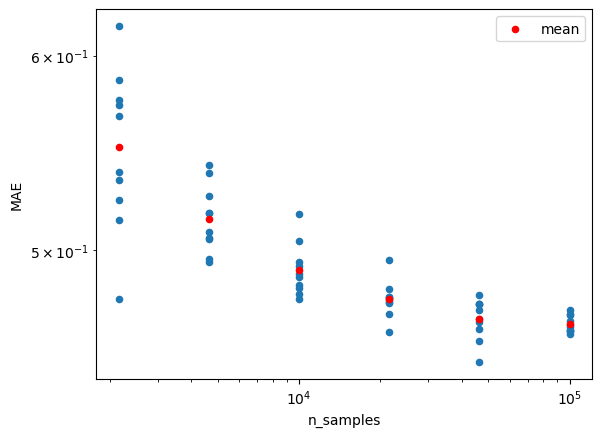

In [32]:
score_name = "MAE"

# n_samples vs MAEを図示する
import matplotlib.pyplot as plt
def plot_n_samples_vs_mae(df_scaling_data, *, xlabel="n_samples", ylabel="MSE"):
    ax = df_scaling_data.plot.scatter(x=xlabel, y=ylabel)
    df_mean = df_scaling_data.groupby(xlabel).mean().reset_index()
    df_mean.plot.scatter(x=xlabel, y=ylabel, ax=ax, c="red", label="mean")
    ax.set_yscale("log")
    ax.set_xscale("log")
    plt.show()

plot_n_samples_vs_mae(df_scaling_data, ylabel=score_name)

ridge


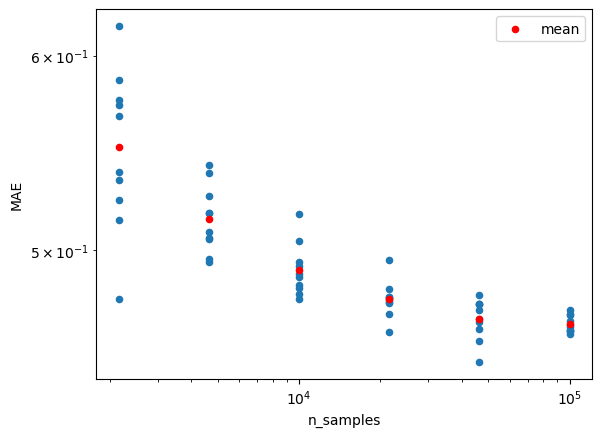

In [33]:
# df_scaling_dataのうち
# n_samplesが小さすぎるデータインスタンスはL(N)カーブに乗らないので捨てる。
print(model_name)
if model_name == "rf":
    df_scaling_data = df_scaling_data_all[df_scaling_data_all["n_samples"]>250].reset_index(drop=True)
elif model_name == "ridge":
    df_scaling_data = df_scaling_data_all[df_scaling_data_all["n_samples"]>1200].reset_index(drop=True)
    
plot_n_samples_vs_mae(df_scaling_data, ylabel=score_name)

In [34]:
df_scaling_data

,n_samples,R2,MAE,MSE
0,2154,0.690997,0.533888,0.457476
1,2154,0.661774,0.572966,0.560919
2,2154,0.727319,0.524352,0.426599
3,2154,0.746593,0.477968,0.389814
4,2154,0.676132,0.566956,0.524233
5,2154,0.658769,0.586447,0.568578
6,2154,0.579121,0.616774,0.697566
7,2154,0.676909,0.538001,0.483121
8,2154,0.711361,0.514637,0.448283
9,2154,0.640116,0.575540,0.580067


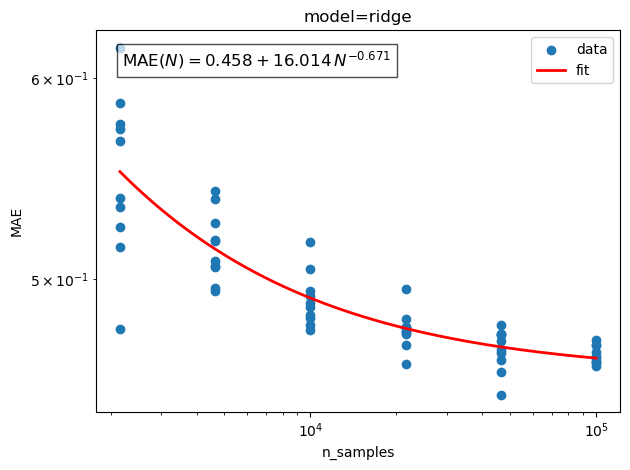

In [35]:
# モデル関数：L(N) = L0 + a * N^(-b)をfitする。

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def scaling_fn(N, L0, a, b):
    # 1) モデル関数：L(N) = L0 + a * N^(-b)
    return L0 + a * N**(-b)
        
def calculate_scaling_relation(df_scaling_data, *, xlabel="n_samples", ylabel="MSE"): 
    # 2) データ
    N = df_scaling_data[xlabel].values.astype(float)  # or model size
    L = df_scaling_data[ylabel].values.astype(float)        # or loss
    
    # 3) 初期値（だいたいでOK）
    L0_init = L.min()
    a_init  = (L.max() - L.min())
    b_init  = 0.1
    
    p0 = (L0_init, a_init, b_init)
    
    # 4) フィット
    popt, pcov = curve_fit(scaling_fn, N, L, p0=p0)
    
    L0_fit, a_fit, b_fit = popt

    return {"L0":L0_fit, "a": a_fit, "b":b_fit}


def plot_scaling_relation(df_scaling_data, scaling_relation,*,xlabel="n_samples", ylabel="MSE", 
                          model_name=None, score_name=None, filename=None):

    N = df_scaling_data[xlabel].values.astype(float)  # or model size
    L = df_scaling_data[ylabel].values.astype(float)        # or loss
    
    L0_fit, a_fit, b_fit = scaling_relation["L0"], scaling_relation["a"], scaling_relation["b"]
                                              
    # 5) フィット結果の可視化
    N_plot = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)
    L_fit  = scaling_fn(N_plot, L0_fit, a_fit, b_fit)
    
    fig, ax = plt.subplots()
    ax.scatter(N, L, label="data")
    ax.plot(N_plot, L_fit, label="fit", c="red", linewidth=2)
    
    ax.set_xscale("log")  # N を log 軸に
    # L を log 軸にしたいなら次も
    ax.set_yscale("log")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # -----------------------------
    # ★ 図にスケーリング式を描く
    # -----------------------------
    if score_name is None:
        eq_text = rf"$L(N) = {L0_fit:.3f} + {a_fit:.3f} \, N^{{-{b_fit:.3f}}}$"
    else:
        eq_text = rf"{score_name}$(N)= {L0_fit:.3f} + {a_fit:.3f} \, N^{{-{b_fit:.3f}}}$"
    ax.text(
        0.05, 0.95, eq_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7)
    )

    if model_name is not None:
        ax.set_title(f"model={model_name}")

    ax.legend()
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename)
    plt.show()

scaling_relation = calculate_scaling_relation(df_scaling_data, ylabel=score_name)

_ = plot_scaling_relation(df_scaling_data, scaling_relation, ylabel=score_name, model_name=model_name,
                          score_name=score_name,
                          filename=f"scaling_law_{model_name}.png")


L0がマイナスではNGです。b<=0.5のはずです。

結果が少し怪しい。
...分布が分かるベイズフィットを行った方が良いだろう。

```
pip install pymc arviz
```


In [36]:
# MCMCを行い関数が与えられた場合の変数の分布を求める。

import pymc as pm
import numpy as np

n_jobs = 4

N = df_scaling_data["n_samples"].values
L = df_scaling_data[score_name].values

with pm.Model() as model:   # ★ model がここで定義される

    L0 = pm.Normal("L0", mu=0.16, sigma=1) # can take <0 and >0
    a  = pm.HalfNormal("a", sigma=1) # >0
    b  = pm.HalfNormal("b", sigma=0.3) # >0

    mu = L0 + a * N**(-b)

    sigma = pm.HalfNormal("sigma", sigma=1)

    L_obs = pm.Normal("L_obs", mu=mu, sigma=sigma, observed=L)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=n_jobs,          
        target_accept=0.9,   
        return_inferencedata=True
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [L0, a, b, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 16 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


赤線のchainは再解析が必要。赤線になってもこのまま次のステップに進む。

Bayesian MCMC の 事後分布（posterior distribution）を図示する

```
pip install arviz
```

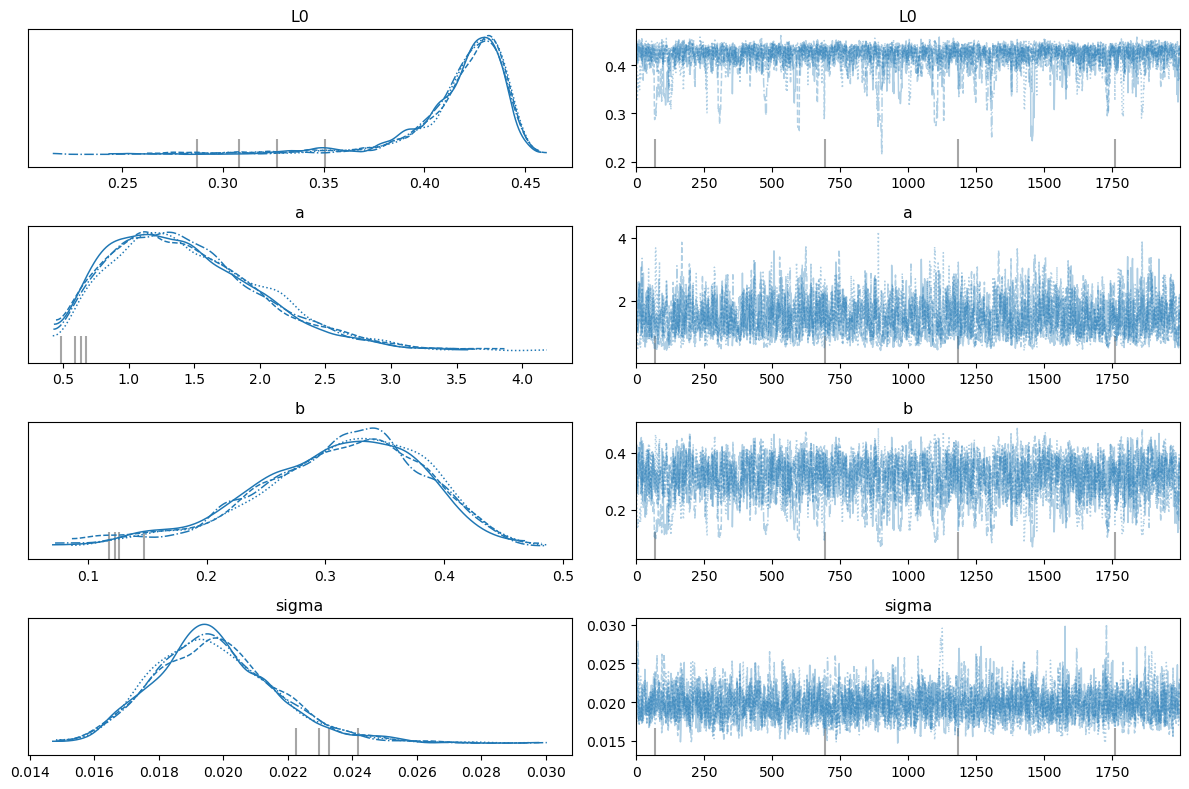

In [37]:
import arviz as az

az.plot_trace(trace)
plt.tight_layout()
plt.show()


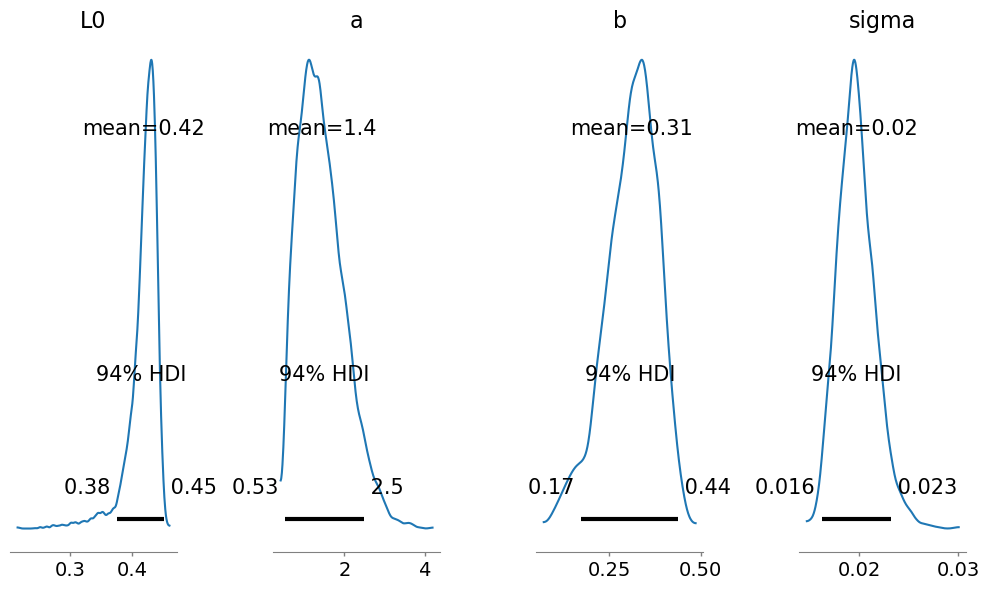

In [38]:
# 拡大して分布を表示する。
# 黒い横棒は95% 信頼区間（エラーバー）を示す。

az.plot_posterior(trace, figsize=(10,6))
plt.tight_layout()
plt.show()

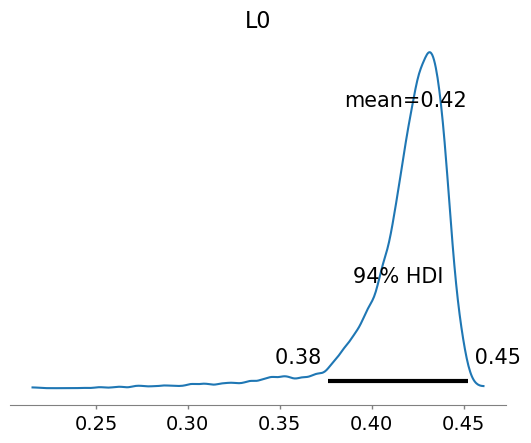

In [39]:
# L0 (Nが無限大時のL）
import matplotlib.pyplot as plt
import arviz as az
az.plot_posterior(trace, var_names=["L0"])
plt.show()

Mode (peak) of L0 = 0.4303204626684709


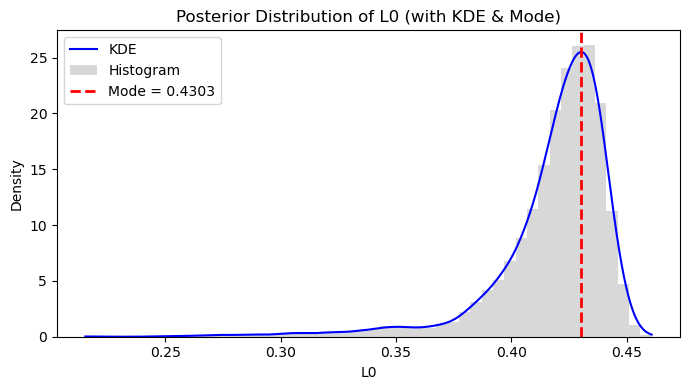

In [40]:
# 平均値でなく、
# Gaussian KDEを用いて荒くfitして、分布最大値を与える値を求める。

import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def gaussian_kde_fit(trace,key="L0"):
    
    # 1. L0 samples
    L0_samples = trace.posterior[key].values.flatten()
    
    # 2. KDE 計算
    kde = gaussian_kde(L0_samples)
    
    # 3. 評価点を生成
    xs = np.linspace(L0_samples.min(), L0_samples.max(), 2000)
    ys = kde(xs)
    
    # 4. mode（ピーク）を計算
    mode_L0 = xs[np.argmax(ys)]
    print(f"Mode (peak) of {key} =", mode_L0)
    
    # 5. Plot
    plt.figure(figsize=(7, 4))
    
    # KDE カーブ
    plt.plot(xs, ys, label="KDE", color="blue")
    
    # ヒストグラム（確率密度として）
    plt.hist(L0_samples, bins=50, density=True, alpha=0.3, color="gray", label="Histogram")
    
    # mode の位置に縦線
    plt.axvline(mode_L0, color="red", linestyle="--", linewidth=2,
                label=f"Mode = {mode_L0:.4f}")
    
    # 軸ラベル・タイトル
    plt.xlabel(key)
    plt.ylabel("Density")
    plt.title(f"Posterior Distribution of {key} (with KDE & Mode)")
    
    # plt.xlim((0, 0.25))
    plt.legend()
    plt.tight_layout()
    plt.show()
    return {key:mode_L0}

peaks = dict()
peaks.update(gaussian_kde_fit(trace))

Mode (peak) of a = 1.1401142806944535


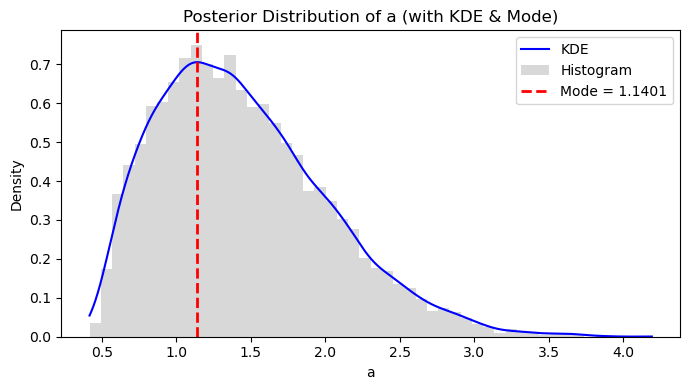

In [41]:
peaks.update(gaussian_kde_fit(trace,key="a"))

Mode (peak) of b = 0.3379897007096411


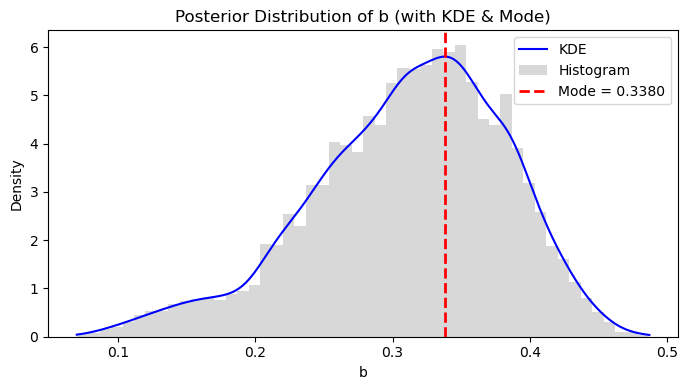

In [42]:
peaks.update(gaussian_kde_fit(trace,key="b"))

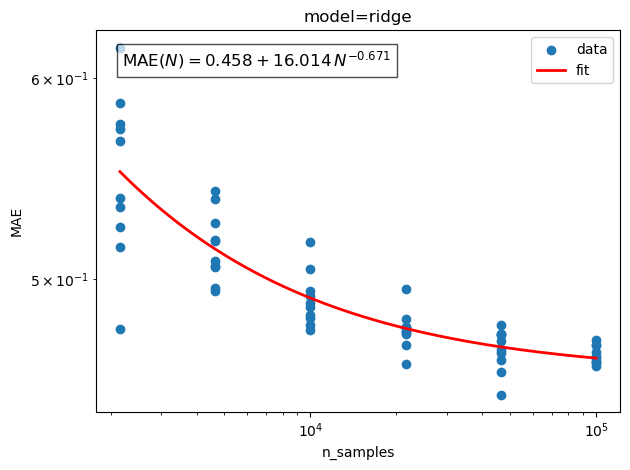

In [43]:
def plot_scaling_relation(df_scaling_data, scaling_relation, *, xlabel="n_samples", ylabel="MSE", 
                          model_name="rf", score_name=None, filename=None):

    N = df_scaling_data[xlabel].values.astype(float)  # or model size
    L = df_scaling_data[ylabel].values.astype(float)        # or loss
    
    L0_fit, a_fit, b_fit = scaling_relation["L0"], scaling_relation["a"], scaling_relation["b"]
                                              
    # 5) フィット結果の可視化
    N_plot = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)
    L_fit  = scaling_fn(N_plot, L0_fit, a_fit, b_fit)
    
    fig, ax = plt.subplots()
    ax.scatter(N, L, label="data")
    ax.plot(N_plot, L_fit, label="fit", c="red", linewidth=2)
    
    ax.set_xscale("log")  # N を log 軸に
    # L を log 軸にしたいなら次も
    ax.set_yscale("log")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # -----------------------------
    # ★ 図にスケーリング式を描く
    # -----------------------------
    if score_name is None:
        eq_text = rf"$L(N) = {L0_fit:.3f} + {a_fit:.3f} \, N^{{-{b_fit:.3f}}}$"
    else:
        eq_text = rf"{score_name}$(N) = {L0_fit:.3f} + {a_fit:.3f} \, N^{{-{b_fit:.3f}}}$"
        
    ax.text(
        0.05, 0.95, eq_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7)
    )


    ax.set_title(f"model={model_name}")
    
    ax.legend()
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename)
    plt.show()
    
_ = plot_scaling_relation(df_scaling_data, scaling_relation, ylabel=score_name, model_name=model_name,
                          score_name=score_name,)


実際の分布は多自由度の分布

１パラメタ毎最大値を確認すると、fitがずれることがある。

In [44]:
# 多自由度分布の最大を与えるパラメタを得る

map_est = pm.find_MAP(model=model)
print(map_est)

Output()

{'L0': array(0.42272606), 'a_log__': array(0.2697815), 'b_log__': array(-1.17007455), 'sigma_log__': array(-3.96397183), 'a': array(1.30967826), 'b': array(0.31034381), 'sigma': array(0.01898755)}


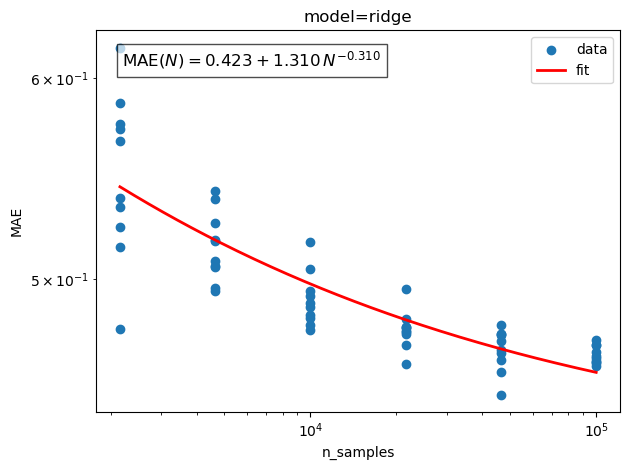

In [45]:
_ = plot_scaling_relation(df_scaling_data, map_est, ylabel=score_name, score_name=score_name, model_name = model_name)

そもそも、fitするのはデータがばらついているので、fitするためのデータを増やしたほうが良い。

In [46]:
model_name, target, score_name

('ridge', 'GAP', 'MAE')